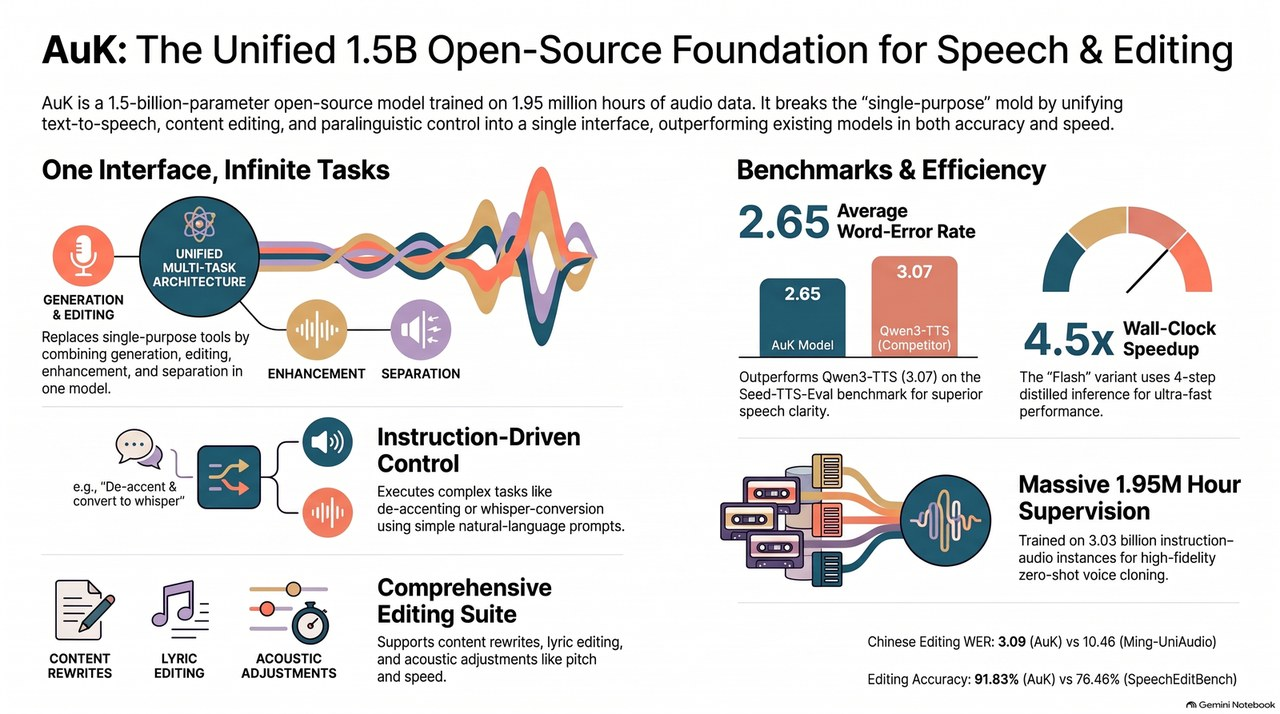


## What AuK can do

**AuK** (1.5B parameters) unifies speech generation and speech editing behind a single
natural-language instruction interface, structured across **five task families**:

### 1. Speech Generation
- **Zero-shot TTS** — synthesises target text in the voice of a provided reference audio clip.
- **Instruct TTS** — generates speech from a natural-language voice description alone (no reference audio).

### 2. Content Editing
- **Speech content editing** — rewrites what is said by replacing, inserting, or removing specific words.
- **Lyric editing** — alters lyrics in a singing performance while preserving the melody and vocal identity.

### 3. Acoustic Editing
- **Pitch / speed / volume** — semitone pitch shifts, speaking-rate changes, and dB-level volume adjustments via text instructions.

### 4. Paralinguistic Editing
- **Emotion & timbre control** — changes tone, emotion, or timbre while keeping the spoken content intact.
- **De-accenting** — removes regional accents while maintaining the speaker's voice identity.
- **Nonverbal & whisper processing** — inserts or removes breaths, laughs, or coughs, and converts between normal and whispered speech.

### 5. Enhancement & Separation
- **Speech enhancement** — restores quality via denoising and dereverberation.
- **Speaker & music separation** — isolates speakers by speaking order or content, and separates vocals from instrumental mixes.

---

**Model variants:** the standard 1.5B base model plus **AuK-Flash**, a distilled variant with
4-step inference (no classifier-free guidance) for a **~4.5× wall-clock speedup**.


In [ ]:
# ------------------------------------------------------------------------------
# Monitor every cell: execution time + GPU memory usage
# ------------------------------------------------------------------------------
# IPython pre/post-run hooks record how long each cell takes and sample the
# VRAM usage of every GPU after each cell. All of this is summarised in a
# table printed by the last cell of the notebook.
# ------------------------------------------------------------------------------
import subprocess
import time

from IPython import get_ipython

_ip = get_ipython()

_stats = {
    "cell_times": [],       # (cell_number, seconds) in execution order
    "gpu_peak_mb": [0, 0],  # peak VRAM seen on each GPU during the run
    "started": None,
    "cell_count": 0,
}


def _gpu_used_mb():
    out = subprocess.run(
        ["nvidia-smi", "--query-gpu=memory.used", "--format=csv,noheader,nounits"],
        capture_output=True, text=True,
    ).stdout
    return [int(x) for x in out.split()]


def _before_cell(info):
    _stats["started"] = time.time()


def _after_cell(info):
    started = _stats["started"]
    _stats["started"] = None
    if started is None:
        return
    duration = time.time() - started
    _stats["cell_count"] += 1
    _stats["cell_times"].append((_stats["cell_count"], duration))
    try:
        used = _gpu_used_mb()
        for i, mb in enumerate(used):
            if i < len(_stats["gpu_peak_mb"]):
                _stats["gpu_peak_mb"][i] = max(_stats["gpu_peak_mb"][i], mb)
    except Exception:
        pass
    print(f"[Cell {_stats['cell_count']} finished in {duration:.1f}s]")


if _ip is not None and "cell_monitor_active" not in _ip.user_ns:
    _ip.user_ns["cell_monitor_active"] = True
    _ip.events.register("pre_run_cell", _before_cell)
    _ip.events.register("post_run_cell", _after_cell)


# Running Tencent's AuK (speech generation & editing) on Kaggle's free T4 x2 GPU

## What this notebook does

It clones and installs **[AuK](https://github.com/Tencent-Hunyuan/AuK)**, Tencent's open-source 1.5B foundation model for speech generation and editing (zero-shot TTS, instruction-driven content/acoustic/paralinguistic editing, speech enhancement, and source separation), loads the **AuK-Base** checkpoint plus its **Qwen2.5-Omni-3B** MLLM encoder from the attached Kaggle datasets, and runs twenty-two of the model's built-in tasks — zero-shot and instruct TTS, content editing (replace / insert / remove), lyric editing, pitch / speed / volume editing, emotion change (happy, sad), timbre conversion, de-accenting, whisper-free nonverbal-sound add/remove, speech enhancement (full, denoise-only, dereverb-only), speaker separation, vocal extraction (singing-only and all human voices), and target-speaker extraction — using the sample audio bundled with the repo, plus two full-length dual-GPU demos (19-28 s clips that OOM a single T4).

1. **Verify the hardware** — confirm the two T4s are attached and visible to PyTorch.
2. **Install AuK** — clone the repo and `pip install` it into this session (inference + CLI only, no Gradio/ComfyUI/training extras).
3. **Copy the weights** — AuK-Base + VAE (~6.8 GB) and the Qwen2.5-Omni-3B encoder, from the attached Kaggle datasets.
4. **Load the model** through AuK's own Python API (`AukInfer`).
5. **Run inference** — zero-shot TTS and content editing, on the reference clips shipped in `assets/demo-input-audio/`.
6. **Play back and sanity-check** the generated audio, right in the notebook.

The final cell prints the same **summary** as before: how long every cell took and how much GPU memory was used.

> **Heads up — this is a different kind of model than the previous version of this notebook ran.** AuK is a diffusion-based speech model, not a GGUF causal-language model, so `llama-cpp-python` and the CUDA-wheel-matching steps from the earlier version don't apply — they've been replaced with AuK's own install/inference path (cloning its repo and using its Python API). Two things worth knowing going in:
> - AuK's docs recommend a fresh Python 3.10 environment (`uv` or `conda`). Spinning up a separate venv mid-session is awkward in a single Jupyter kernel, so this notebook installs straight into Kaggle's existing Python kernel instead. If the install cell errors out on a dependency-resolution or Python-version message, that's almost certainly why.
> - The weights ship as the Kaggle datasets `dsptlp/auk-base`, `dsptlp/qwen25-omni-shard13`, and `dsptlp/qwen25-omni-shard2` — nothing is downloaded from Hugging Face at runtime. Internet is only needed for the repo clone and `pip install` in section 2.
>
> I haven't been able to run this end to end myself — no GPU or general internet access in the environment I'm working in — so treat it as a solid first draft built directly from AuK's own docs rather than a pipeline I've personally verified, and let me know what breaks.


## 1. Verify GPU availability

A Kaggle session with the “GPU T4 x2” accelerator exposes two Tesla T4s. AuK's combined footprint (diffusion transformer + VAE + Qwen2.5-Omni-3B encoder) is small next to the LLMs the previous version of this notebook loaded, so it will likely fit on a single T4's 15 GB in bf16 — but both GPUs are available if needed. The monitor hooks registered in the first cell time every cell from here on; the full timing table and GPU memory report are printed at the end of the notebook.


In [ ]:
# List the GPUs attached to this session (expect two Tesla T4).
!nvidia-smi


In [ ]:
# Confirm PyTorch sees both GPUs and report the CUDA version it was built for.
import torch

print("torch:", torch.__version__, "| built for CUDA:", torch.version.cuda)
print("device count:", torch.cuda.device_count())

for i in range(torch.cuda.device_count()):
    props = torch.cuda.get_device_properties(i)
    print(
        i,
        torch.cuda.get_device_name(i),
        round(props.total_memory / 1024**3, 1),
        "GB",
    )


## 2. Install AuK

Clone [Tencent-Hunyuan/AuK](https://github.com/Tencent-Hunyuan/AuK) and install it with `pip install -e .` — core inference and CLI only, since we don't need the Gradio demo, ComfyUI nodes, or the fine-tuning extras here. The package installs PyTorch/TorchAudio/TorchVision itself, so this cell snapshots the image's CUDA torch stack before installing and force-reinstalls the same versions afterwards — otherwise AuK's pins swap in non-CUDA builds and `libtorchaudio` fails to load. The cell after this one prints whatever versions ended up on disk. If a later cell throws a CUDA or import error that section 1 didn't, use Kaggle's **Session → Restart & Run All** rather than just re-running cells — a fresh process is the reliable way to pick up whatever actually landed on disk.


In [ ]:
# Clone the AuK repo and install it (inference + CLI only) into this session.
import re
import subprocess

AUK_DIR = "/kaggle/working/AuK"

# Snapshot the Kaggle image's CUDA-native stack BEFORE AuK's install replaces
# it, then restore it afterwards. AuK's pins pull non-CUDA torch builds (broken
# libtorchaudio: 'undefined symbol: c10_cuda_check_implementation'), a Pillow
# missing PIL._typing._Ink, and a numpy/scipy pair where scipy cannot import
# numpy._core.umath._center.
KEEP = {}
for line in subprocess.check_output(["pip", "freeze"], text=True).splitlines():
    m = re.match(r"^(torch|torchaudio|torchvision|pillow|numpy|scipy)==(.+)$", line.strip())
    if m:
        KEEP[m.group(1)] = m.group(2)

# AuK is pinned to a specific revision (verified with the fp16/bf16 and mask
# patches on T4). main moves fast and its lower-VRAM commits keep changing the
# exact lines the load cell patches, so grab the commit tarball instead of git.
import glob
import os
import tarfile
import urllib.request

AUK_REV = "e1c935e81e35"
TARBALL = f"/kaggle/working/auk-{AUK_REV}.tar.gz"
print(f"downloading AuK @ {AUK_REV} ...")
urllib.request.urlretrieve(
    f"https://github.com/Tencent-Hunyuan/AuK/archive/{AUK_REV}.tar.gz", TARBALL
)
with tarfile.open(TARBALL, "r:gz") as tf:
    tf.extractall("/kaggle/working", filter="data")
extracted = glob.glob("/kaggle/working/AuK-*")[0]  # top dir carries the full 40-char sha
os.rename(extracted, AUK_DIR)
subprocess.run(["pip", "install", "-q", "-e", "."], cwd=AUK_DIR, check=True)

if KEEP:
    pins = [f"{pkg}=={ver}" for pkg, ver in KEEP.items()]
    print("restoring image versions:", pins)
    torch_pins = [p for p in pins if p.startswith("torch")]
    other_pins = [p for p in pins if not p.startswith("torch")]
    if torch_pins:
        subprocess.run(
            ["pip", "install", "-q", "--force-reinstall", *torch_pins,
             "--index-url", "https://download.pytorch.org/whl/cu128"],
            check=True,
        )
    if other_pins:
        subprocess.run(["pip", "install", "-q", "--force-reinstall", *other_pins], check=True)

print("AuK installed at", AUK_DIR)


In [ ]:
# Sanity-check which torch / torchaudio / torchvision ended up on disk after
# the install above.
!pip show torch torchaudio torchvision 2>/dev/null | grep -E "^(Name|Version):"


## 3. Copy the weights

AuK-Base (diffusion transformer + VAE, ~6.8 GB combined) and the Qwen2.5-Omni-3B MLLM encoder it depends on are shipped as the attached Kaggle datasets `dsptlp/auk-base`, `dsptlp/qwen25-omni-shard13` (shards 1+3), and `dsptlp/qwen25-omni-shard2` (shard 2) — nothing is downloaded from Hugging Face at runtime. (The earlier version of this notebook pulled the weights straight from Hugging Face instead; the distilled AuK-Flash variant is not shipped here.)

The `ckpts/AuK` + `ckpts/Qwen2.5-Omni-3B` layout below matches what AuK's docs expect — it's how `AukInfer` finds the encoder without being told its path explicitly.


In [ ]:
# Copy the AuK-Base checkpoint and its Qwen2.5-Omni-3B encoder from the
# attached Kaggle datasets (dsptlp/auk-base, dsptlp/qwen25-omni-shard13,
# dsptlp/qwen25-omni-shard2) instead of downloading from Hugging Face.
# The Qwen encoder ships as two datasets (Kaggle drops uploads larger than
# ~9 GB), so every mounted shard dir is copied into the same ckpts dir.
import glob
import os
import shutil

CKPT_SUBDIR = "AuK"
CKPT_FILENAME = "auk_base.safetensors"

CKPT_DIR = f"{AUK_DIR}/ckpts/{CKPT_SUBDIR}"
QWEN_DIR = f"{AUK_DIR}/ckpts/Qwen2.5-Omni-3B"

# Locate the mounted datasets by marker files (mount-path-proof).
auk_markers = glob.glob("/kaggle/input/**/auk_base.safetensors", recursive=True)
qwen_markers = glob.glob("/kaggle/input/**/model-0000*-of-00003.safetensors", recursive=True)

if not auk_markers:
    raise RuntimeError("AuK dataset not found under /kaggle/input — attach dsptlp/auk-base")
if not qwen_markers:
    raise RuntimeError("Qwen2.5-Omni-3B dataset not found under /kaggle/input — attach dsptlp/qwen25-omni-shard13 and dsptlp/qwen25-omni-shard2")

os.makedirs(CKPT_DIR, exist_ok=True)
os.makedirs(QWEN_DIR, exist_ok=True)

qwen_srcs = sorted({os.path.dirname(m) for m in qwen_markers})
for src, dst, label in [(os.path.dirname(auk_markers[0]), CKPT_DIR, "AuK")]:
    print(f"copying {label}: {src} -> {dst}")
    shutil.copytree(src, dst, dirs_exist_ok=True)

for src in qwen_srcs:
    print(f"copying Qwen2.5-Omni-3B: {src} -> {QWEN_DIR}")
    shutil.copytree(src, QWEN_DIR, dirs_exist_ok=True)

assert os.path.isfile(f"{CKPT_DIR}/{CKPT_FILENAME}"), "AuK checkpoint missing after copy"
for i in (1, 2, 3):
    assert os.path.isfile(f"{QWEN_DIR}/model-0000{i}-of-00003.safetensors"), f"Qwen shard {i} missing after copy"

print("done")


## 4. Load the model

`AukInfer` takes the checkpoint's `config.yaml` and its `.safetensors` weights. A single T4's ~14.6 GiB can't hold AuK's default FP32 DiT + bf16 Qwen encoder + VAE, so the cell patches `infer_auk.py` to build the DiT in FP16 (sampling autocasts to FP16 anyway, ~4 GB saved). It loads the VAE automatically from `vae.safetensors` next to the checkpoint. `config.yaml` references the Qwen2.5-Omni-3B encoder with a repo-relative path, so the cell passes `qwen_path=QWEN_DIR` to point `AukInfer` at the copied directory.


In [ ]:
import sys

sys.path.insert(0, f"{AUK_DIR}/src")  # belt-and-suspenders in case the editable
                                       # install needs a kernel restart to be
                                       # picked up automatically

    # A T4 has only ~14.6 GiB usable VRAM; AuK loads the DiT in FP32 (~8 GB) on top
    # of the bf16 Qwen encoder (~6.4 GB) + VAE, which OOMs. Load the DiT weights in
    # FP16 (saves ~4 GB) but keep the default bf16 autocast — fp16 autocast overflows
    # during sampling and produces NaN latents.
AUK_INFER_PY = f"{AUK_DIR}/src/auk/infer/infer_auk.py"
_src = open(AUK_INFER_PY).read()
_old = "model = model.to(torch.float32)"
assert _old in _src, "unexpected infer_auk.py layout"
_src = _src.replace(_old, "model = model.to(torch.float16)")

# Long source clips hit an attention-mask/sequence-length mismatch in AuK (mask
# built from the audio features only, query includes text). Masks are all-True
# for single-sample inference, so disabling them is numerically identical and
# avoids the shape error.
_old2 = 'model_arc["attn_backend"] = "torch"'
assert _old2 in _src, "unexpected infer_auk.py layout"
_src = _src.replace(
    _old2,
    'model_arc["attn_backend"] = "torch"\n'
    '        model_arc["attn_mask_enabled"] = False',
)
open(AUK_INFER_PY, "w").write(_src)

# Upstream bug: for long source audio the Qwen processor's attention_mask covers
# only the text tokens, but the projected text embeddings include audio feature
# frames, so masked_fill blows up. Single-sample inference has no padding, so
# rebuild the mask as all-True from the actual hidden-state length.
CFM_EDIT_PY = f"{AUK_DIR}/src/auk/model/cfm_edit.py"
_cfm = open(CFM_EDIT_PY).read()
_old3 = '        attention_mask = cond_inputs["attention_mask"]'
assert _old3 in _cfm, "unexpected cfm_edit.py layout"
_cfm = _cfm.replace(
    _old3,
    "        attention_mask = None  # rebuilt all-True after forward (single-sample, no padding)\n"
    "        cond_inputs[\"attention_mask\"] = None  # LLM: single-sample, all positions valid",
)
_old4 = "        return hidden, attention_mask.bool()"
assert _old4 in _cfm, "unexpected cfm_edit.py layout"
_cfm = _cfm.replace(
    _old4,
    "        seq_len = hidden.shape[1]\n"
    "        return hidden, torch.ones(hidden.shape[0], seq_len, dtype=torch.bool, device=hidden.device)",
)
open(CFM_EDIT_PY, "w").write(_cfm)

# Belt-and-braces: force the text mask to an all-True mask matching the embedding
# length inside the transformer forward (the Qwen processor's attention_mask can
# cover only the text tokens for long source audio).
FLUX_PY = f"{AUK_DIR}/src/auk/model/flux2_edit.py"
_flux = open(FLUX_PY).read()
_old5 = (
    "        if c_mask is None:\n"
    "            c_mask = text.abs().sum(-1) > 0  # [B, nt], True = valid\n"
)
assert _old5 in _flux, "unexpected flux2_edit.py layout"
open(FLUX_PY, "w").write(_flux.replace(
    _old5,
    "        # single-sample inference: no padding, force all-True mask matching\n"
    "        # the embedding length (processor masks can be text-only for long audio)\n"
    "        c_mask = torch.ones(text.shape[0], text.shape[1], dtype=torch.bool, device=text.device)\n",
))

# The cfg branch caches project_text() output across odeint steps, but the cache
# survives task boundaries (and failed runs), poisoning the next task when its
# text length differs. Only reuse the cache when the length matches.
_flux = open(FLUX_PY).read()
_old7 = "        if cache and self.text_cond is not None:\n"
assert _old7 in _flux, "unexpected flux2_edit.py layout"
_flux = _flux.replace(
    _old7,
    "        if cache and self.text_cond is not None and self.text_cond.shape[1] == text.shape[1]:\n",
)
_old8 = "        if cache and self.text_uncond is not None:\n"
assert _old8 in _flux, "unexpected flux2_edit.py layout"
_flux = _flux.replace(
    _old8,
    "        if cache and self.text_uncond is not None and self.text_uncond.shape[1] == text.shape[1]:\n",
)
open(FLUX_PY, "w").write(_flux)

# --- dual-GPU: keep the Qwen text encoder on the second T4 ---
# GPU 0 then has room for the long-sequence DiT activations, so full-length
# clips (10-28 s) run instead of OOMing. The encoder stays on cuda:1 and
# encode_text() moves inputs there and pulls the embeddings back to cuda:0.
_inf2 = open(AUK_INFER_PY).read()
_old9 = "        self.model = model.to(load_device)\n"
assert _old9 in _inf2, "unexpected infer_auk.py layout"
_inf2 = _inf2.replace(
    _old9,
    _old9 + "        self.model.text_encoder.to(\"cuda:1\")  # dual-GPU: Qwen on the second T4\n",
)
open(AUK_INFER_PY, "w").write(_inf2)

_cfm2 = open(CFM_EDIT_PY).read()
_oldA = "            cond_inputs = cond_inputs.to(device)"
assert _oldA in _cfm2, "unexpected cfm_edit.py layout"
_cfm2 = _cfm2.replace(
    _oldA,
    "            te_device = next(self.text_encoder.parameters()).device\n"
    "            cond_inputs = cond_inputs.to(te_device)",
)
_oldB = "            cond_inputs = {k: (v.to(device) if torch.is_tensor(v) else v) for k, v in cond_inputs.items()}"
assert _oldB in _cfm2, "unexpected cfm_edit.py layout"
_cfm2 = _cfm2.replace(
    _oldB,
    "            cond_inputs = {k: (v.to(te_device) if torch.is_tensor(v) else v) for k, v in cond_inputs.items()}",
)
_oldC = "        text_embeds, context_mask = self.encode_text(text, device)"
assert _oldC in _cfm2, "unexpected cfm_edit.py layout"
_cfm2 = _cfm2.replace(
    _oldC,
    _oldC + "\n        text_embeds = text_embeds.to(device)\n        context_mask = context_mask.to(device)",
)
_oldD = "    def device(self):\n        return next(self.parameters()).device"
assert _oldD in _cfm2, "unexpected cfm_edit.py layout"
_cfm2 = _cfm2.replace(
    _oldD,
    "    def device(self):\n"
    "        # dual-GPU: the DiT lives on GPU 0, the Qwen encoder on GPU 1\n"
    "        return next(self.transformer.parameters()).device",
)
_oldE = "        weights = F.softmax(self.layer_weights, dim=0)"
assert _oldE in _cfm2, "unexpected cfm_edit.py layout"
_cfm2 = _cfm2.replace(
    _oldE,
    "        weights = F.softmax(self.layer_weights.to(stacked.device), dim=0)",
)
_oldF = "        hidden = (stacked * weights[:, None, None, None]).sum(dim=0) * self.layer_scale"
assert _oldF in _cfm2, "unexpected cfm_edit.py layout"
_cfm2 = _cfm2.replace(
    _oldF,
    "        hidden = (stacked * weights[:, None, None, None]).sum(dim=0) * self.layer_scale.to(stacked.device)",
)
open(CFM_EDIT_PY, "w").write(_cfm2)

from auk.infer.infer_auk import AukInfer, save_audio

engine = AukInfer(
    f"{CKPT_DIR}/config.yaml",
    f"{CKPT_DIR}/{CKPT_FILENAME}",
    qwen_path=QWEN_DIR,  # config.yaml uses a repo-relative path; point it at the copied dir
)


## 5. Run inference

Two of AuK's built-in tasks first, then a second cell runs twenty more Cookbook examples, and a final demo cell runs the full-length two-speaker clips on both GPUs (instruct TTS without reference audio, pitch / speed editing, de-accent, enhancement, speaker separation, timbre conversion, and lyric editing) — all using the reference clips bundled with the repo under `assets/demo-input-audio/`:

- **Zero-shot TTS** — read a new sentence in the voice of a reference clip.
- **Speech content editing** — replace a phrase in an existing recording while keeping the same voice and delivery.

Every task goes through the same `messages` interface as a chat completion — a list of `text`/`audio` content blocks — and `gen_seconds` tells the diffusion model roughly how long the output should run. The [Cookbook](https://github.com/Tencent-Hunyuan/AuK/blob/main/docs/COOKBOOK.md) has the full instruction templates for every other supported task (pitch/speed/volume editing, emotion, timbre, de-accent, enhancement, separation, and more) if you want to swap these out.


In [ ]:
# ------------------------------------------------------------------------------
# Run two representative AuK tasks and save + play back whatever comes out.
# Each task is wrapped independently so one failure doesn't take down the rest.
# ------------------------------------------------------------------------------
import os
import traceback

from IPython.display import Audio, HTML, display

def show_compare(task):
    # Play the original source clip (if any) next to the edited result.
    src = None
    for _m in task["messages"]:
        for _c in _m["content"]:
            if isinstance(_c, dict) and _c.get("type") == "audio":
                src = _c.get("audio")
                break
    if src:
        _html = (
            '<div style="display:flex;gap:24px;flex-wrap:wrap">'
            f'<div><b>Original</b><br>{Audio(src)._repr_html_()}</div>'
            f'<div><b>Edited</b><br>{Audio(task["output"])._repr_html_()}</div>'
            "</div>"
        )
        display(HTML(_html))
    else:
        display(Audio(task["output"]))

OUT_DIR = "/kaggle/working/outputs"
os.makedirs(OUT_DIR, exist_ok=True)

tasks = [
    {
        "name": "zero_shot_tts",
        "gen_seconds": 6.0,
        "output": f"{OUT_DIR}/out_tts.wav",
        "messages": [
            {
                "role": "user",
                "content": [
                    {
                        "type": "text",
                        "text": (
                            "Say the following with the same voice: 'Ladies and "
                            "gentlemen, it's an honor to have the opportunity to "
                            "address such a distinguished audience'"
                        ),
                    },
                    {
                        "type": "audio",
                        "audio": f"{AUK_DIR}/assets/demo-input-audio/zero-shot-tts/ref.wav",
                    },
                ],
            }
        ],
    },
    {
        "name": "content_edit",
        "gen_seconds": 7.0,
        "output": f"{OUT_DIR}/out_content_edit.wav",
        "messages": [
            {
                "role": "user",
                "content": [
                    {
                        "type": "text",
                        "text": (
                            "Replace 'but accepting what we cannot have' with 'and "
                            "living well with dreams unmet'."
                        ),
                    },
                    {
                        "type": "audio",
                        "audio": f"{AUK_DIR}/assets/demo-input-audio/content-edit/content.wav",
                    },
                ],
            }
        ],
    },
]

results = []
for task in tasks:
    print(f"\n=== {task['name']} ===")
    try:
        audio, sample_rate = engine.generate(task["messages"], gen_seconds=task["gen_seconds"])
        save_audio(audio, sample_rate, task["output"])
        size_kb = os.path.getsize(task["output"]) / 1024
        print(f"RESULT: SUCCESS -> {task['output']}  ({size_kb:.0f} KB, {sample_rate} Hz)")
        results.append((task["name"], task["output"], True))
        show_compare(task)
    except Exception:
        print(f"RESULT: FAILED on {task['name']}")
        traceback.print_exc()
        results.append((task["name"], task["output"], False))

print("\nSummary:")
for name, path, ok in results:
    print(f"  {name}: {'OK -> ' + path if ok else 'FAILED'}")


In [ ]:
# ------------------------------------------------------------------------------
# More speech generation & editing examples from AuK's Cookbook: instruct TTS
# (no reference audio), pitch / speed editing, de-accent, speech enhancement,
# speaker separation, timbre conversion, and lyric editing. Each task is
# wrapped independently so one failure doesn't take down the rest.
# ------------------------------------------------------------------------------
import os
import traceback

from IPython.display import Audio, HTML, display

def show_compare(task):
    # Play the original source clip (if any) next to the edited result.
    src = None
    for _m in task["messages"]:
        for _c in _m["content"]:
            if isinstance(_c, dict) and _c.get("type") == "audio":
                src = _c.get("audio")
                break
    if src:
        _html = (
            '<div style="display:flex;gap:24px;flex-wrap:wrap">'
            f'<div><b>Original</b><br>{Audio(src)._repr_html_()}</div>'
            f'<div><b>Edited</b><br>{Audio(task["output"])._repr_html_()}</div>'
            "</div>"
        )
        display(HTML(_html))
    else:
        display(Audio(task["output"]))

A = f"{AUK_DIR}/assets/demo-input-audio"

# Several demo clips are far longer than what fits a single T4 in this config
# (ref + gen latents run through the DiT; ~10 s of audio is the practical cap).
# crop_src() caps any source clip at MAX_SRC_SEC so every example runs.
import torchaudio

MAX_SRC_SEC = 6.0
CROP_DIR = "/kaggle/working/crops"
os.makedirs(CROP_DIR, exist_ok=True)

def crop_src(path: str) -> str:
    wav, sr = torchaudio.load(path)
    if wav.shape[1] > int(MAX_SRC_SEC * sr):
        wav = wav[:, : int(MAX_SRC_SEC * sr)]
    out = os.path.join(CROP_DIR, os.path.basename(path))
    torchaudio.save(out, wav, sr)
    return out

extra_tasks = [
    {
        "name": "instruct_tts",
        "gen_seconds": 1.7,
        "output": f"{OUT_DIR}/out_instruct_tts.wav",
        "messages": [
            {
                "role": "user",
                "content": [
                    {
                        "type": "text",
                        "text": (
                            "Based on the following description: \"一位二十多岁的女性，"
                            "面对刚到家的伴侣，以温柔、关心且略带撒娇的语气轻声诉说。"
                            "她的声音柔和亲密，语速稍缓，音量适中，音色甜美自然，"
                            "在短语结尾处语调温暖地上扬。她正向伴侣问候回家，"
                            "并温柔询问今日工作如何。\", "
                            "generate speech content \"Welcome home, how was work today?\"."
                        ),
                    },
                ],
            }
        ],
    },
    {
        "name": "pitch_edit",
        "gen_seconds": None,
        "output": f"{OUT_DIR}/out_pitch.wav",
        "messages": [
            {
                "role": "user",
                "content": [
                    {"type": "text", "text": "Raise the pitch by 2 semitones."},
                    {"type": "audio", "audio": f"{A}/pitch/pitch-1-input.wav"},
                ],
            }
        ],
    },
    {
        "name": "speed_edit",
        "gen_seconds": 6.86,  # 1.5x of the source length
        "output": f"{OUT_DIR}/out_speed.wav",
        "messages": [
            {
                "role": "user",
                "content": [
                    {"type": "text", "text": "Adjust the speech speed to 1.5x."},
                    {"type": "audio", "audio": f"{A}/speed/speed-edit-1-input.wav"},
                ],
            }
        ],
    },
    {
        "name": "de_accent",
        "gen_seconds": None,
        "output": f"{OUT_DIR}/out_deaccent.wav",
        "messages": [
            {
                "role": "user",
                "content": [
                    {"type": "text", "text": "请把方言腔改成标准普通话发音,音色维持一致。"},
                    {"type": "audio", "audio": f"{A}/accent/accent-sichuan-input.wav"},
                ],
            }
        ],
    },
    {
        "name": "speech_enhance",
        "gen_seconds": None,
        "output": f"{OUT_DIR}/out_enhance.wav",
        "messages": [
            {
                "role": "user",
                "content": [
                    {
                        "type": "text",
                        "text": (
                            "Preserve all speakers, remove noise and reverberation, "
                            "and output clean speech of the same length."
                        ),
                    },
                    {"type": "audio", "audio": f"{A}/se/se-zh-1-input.wav"},
                ],
            }
        ],
    },
    {
        "name": "speech_separation",
        "gen_seconds": None,
        "output": f"{OUT_DIR}/out_separation.wav",
        "messages": [
            {
                "role": "user",
                "content": [
                    {
                        "type": "text",
                        "text": (
                            "Please keep the second speaker to start talking and remove "
                            "the other speakers, outputting a single clean speech track."
                        ),
                    },
                    {"type": "audio", "audio": crop_src(f"{A}/ss/zh-1-input.wav")},
                ],
            }
        ],
    },
    {
        "name": "timbre_vc",
        "gen_seconds": None,
        "output": f"{OUT_DIR}/out_timbre.wav",
        "messages": [
            {
                "role": "user",
                "content": [
                    {
                        "type": "text",
                        "text": (
                            "Keep the spoken content unchanged and change the timbre to: "
                            "\"a deep, calm male voice\"."
                        ),
                    },
                    {"type": "audio", "audio": f"{A}/vc/vc-1-input.wav"},
                ],
            }
        ],
    },
    {
        "name": "lyric_edit",
        "gen_seconds": None,
        "output": f"{OUT_DIR}/out_lyric_edit.wav",
        "messages": [
            {
                "role": "user",
                "content": [
                    {
                        "type": "text",
                        "text": (
                            "Change \"rear view\" to \"like you\" in the vocal recording."
                        ),
                    },
                    {"type": "audio", "audio": f"{A}/vocal-edit/vocaledit-en-1-input.wav"},
                ],
            }
        ],
    },
    {
        "name": "volume_edit",
        "gen_seconds": None,
        "output": f"{OUT_DIR}/out_volume.wav",
        "messages": [
            {
                "role": "user",
                "content": [
                    {"type": "text", "text": "Increase the volume by 10 dB."},
                    {"type": "audio", "audio": f"{A}/energy/energy-edit-1-input.wav"},
                ],
            }
        ],
    },
    {
        "name": "emotion_edit",
        "gen_seconds": None,
        "output": f"{OUT_DIR}/out_emotion.wav",
        "messages": [
            {
                "role": "user",
                "content": [
                    {"type": "text", "text": "Change the emotion to happy."},
                    {"type": "audio", "audio": f"{A}/emotion-edit/en-1-input.wav"},
                ],
            }
        ],
    },
    {
        "name": "vocal_extraction",
        "gen_seconds": None,
        "output": f"{OUT_DIR}/out_vocal_extraction.wav",
        "messages": [
            {
                "role": "user",
                "content": [
                    {"type": "text", "text": "Keep the clean singing voice, drop all other audio."},
                    {"type": "audio", "audio": crop_src(f"{A}/vocal-extraction/vocal-1-input.wav")},
                ],
            }
        ],
    },
    {
        "name": "target_speaker_extraction",
        "gen_seconds": None,
        "output": f"{OUT_DIR}/out_target_speaker.wav",
        "messages": [
            {
                "role": "user",
                "content": [
                    {
                        "type": "text",
                        "text": (
                            "Keep only the speaker who says \"get what\" and remove "
                            "all other speakers."
                        ),
                    },
                    {"type": "audio", "audio": crop_src(f"{A}/ss/en-1-input.wav")},
                ],
            }
        ],
    },
    {
        "name": "nonverbal_remove",
        "gen_seconds": 6.0,
        "output": f"{OUT_DIR}/out_nonverbal_remove.wav",
        "messages": [
            {
                "role": "user",
                "content": [
                    {"type": "text", "text": "Remove the humming from the audio."},
                    {"type": "audio", "audio": crop_src(f"{A}/nv/en-d-input.wav")},
                ],
            }
        ],
    },
    {
        "name": "nonverbal_add",
        "gen_seconds": 6.0,
        "output": f"{OUT_DIR}/out_nonverbal_add.wav",
        "messages": [
            {
                "role": "user",
                "content": [
                    {"type": "text", "text": "Add a cough before \"We tested\""},
                    {"type": "audio", "audio": crop_src(f"{A}/nv/en-c-input.wav")},
                ],
            }
        ],
    },
    {
        "name": "content_insert",
        "gen_seconds": 7.0,
        "output": f"{OUT_DIR}/out_content_insert.wav",
        "messages": [
            {
                "role": "user",
                "content": [
                    {"type": "text", "text": "Add \"and remember the good times\" after \"accepting what we cannot have\"."},
                    {"type": "audio", "audio": f"{A}/content-edit/content.wav"},
                ],
            }
        ],
    },
    {
        "name": "content_remove",
        "gen_seconds": 7.0,
        "output": f"{OUT_DIR}/out_content_remove.wav",
        "messages": [
            {
                "role": "user",
                "content": [
                    {"type": "text", "text": "Remove \"but accepting what we cannot have\"."},
                    {"type": "audio", "audio": f"{A}/content-edit/content.wav"},
                ],
            }
        ],
    },
    {
        "name": "emotion_sad",
        "gen_seconds": None,
        "output": f"{OUT_DIR}/out_emotion_sad.wav",
        "messages": [
            {
                "role": "user",
                "content": [
                    {"type": "text", "text": "Change the emotion to sad."},
                    {"type": "audio", "audio": f"{A}/emotion-edit/en-1-input.wav"},
                ],
            }
        ],
    },
    {
        "name": "enhance_denoise",
        "gen_seconds": None,
        "output": f"{OUT_DIR}/out_denoise.wav",
        "messages": [
            {
                "role": "user",
                "content": [
                    {"type": "text", "text": "Remove only the background noise, preserve everything else, and output audio of the same length."},
                    {"type": "audio", "audio": f"{A}/se/se-zh-1-input.wav"},
                ],
            }
        ],
    },
    {
        "name": "enhance_dereverb",
        "gen_seconds": None,
        "output": f"{OUT_DIR}/out_dereverb.wav",
        "messages": [
            {
                "role": "user",
                "content": [
                    {"type": "text", "text": "Remove only the room reverberation, preserve everything else, and output audio of the same length."},
                    {"type": "audio", "audio": f"{A}/se/se-zh-1-input.wav"},
                ],
            }
        ],
    },
    {
        "name": "vocal_all_human",
        "gen_seconds": None,
        "output": f"{OUT_DIR}/out_vocal_all_human.wav",
        "messages": [
            {
                "role": "user",
                "content": [
                    {"type": "text", "text": "Keep all human voices, including speech and singing, and remove everything else."},
                    {"type": "audio", "audio": crop_src(f"{A}/vocal-extraction/vocal-1-input.wav")},
                ],
            }
        ],
    },
]

results = []
for task in extra_tasks:
    print(f"\n=== {task['name']} ===")
    try:
        if torch.cuda.is_available():
            torch.cuda.empty_cache()
        audio, sample_rate = engine.generate(task["messages"], gen_seconds=task["gen_seconds"])
        save_audio(audio, sample_rate, task["output"])
        size_kb = os.path.getsize(task["output"]) / 1024
        print(f"RESULT: SUCCESS -> {task['output']}  ({size_kb:.0f} KB, {sample_rate} Hz)")
        results.append((task["name"], task["output"], True))
        show_compare(task)
    except Exception:
        print(f"RESULT: FAILED on {task['name']}")
        traceback.print_exc()
        results.append((task["name"], task["output"], False))

print("\nSummary:")
for name, path, ok in results:
    print(f"  {name}: {'OK -> ' + path if ok else 'FAILED'}")


## 6. Dual-GPU demo: full-length clips

The load cell places the Qwen2.5-Omni-3B encoder on **GPU 1** (`cuda:1`), leaving GPU 0 with the DiT, VAE, and activations. That roughly doubles the usable VRAM (2× T4 ≈ 29.8 GiB), which is exactly what the long two-speaker clips need: the separation source is 19.2 s and the target-speaker source 28 s (ref + gen latents both run through the DiT, so those would need ~38-56 s of latent audio on a single GPU — it OOMs).

Both tasks below use the **uncropped** demo files; each is wrapped so a failure doesn't take down the rest.


In [ ]:
# ------------------------------------------------------------------------------
# Dual-GPU demos: full-length clips that OOM a single T4. With the Qwen text
# encoder on cuda:1, GPU 0 only holds the DiT + VAE + activations, so the
# uncropped two-speaker clips (19.2 s / 28 s) fit. Previously these crashed
# with CUDA out of memory.
# ------------------------------------------------------------------------------
import os
import traceback

from IPython.display import Audio, HTML, display

def show_compare(task):
    # Play the original source clip (if any) next to the edited result.
    src = None
    for _m in task["messages"]:
        for _c in _m["content"]:
            if isinstance(_c, dict) and _c.get("type") == "audio":
                src = _c.get("audio")
                break
    if src:
        _html = (
            '<div style="display:flex;gap:24px;flex-wrap:wrap">'
            f'<div><b>Original</b><br>{Audio(src)._repr_html_()}</div>'
            f'<div><b>Edited</b><br>{Audio(task["output"])._repr_html_()}</div>'
            "</div>"
        )
        display(HTML(_html))
    else:
        display(Audio(task["output"]))

big_tasks = [
    {
        "name": "separation_full",
        "gen_seconds": None,
        "output": f"{OUT_DIR}/out_separation_full.wav",
        "messages": [
            {
                "role": "user",
                "content": [
                    {
                        "type": "text",
                        "text": (
                            "Please keep the second speaker to start talking and remove "
                            "the other speakers, outputting a single clean speech track."
                        ),
                    },
                    {"type": "audio", "audio": f"{A}/ss/zh-1-input.wav"},
                ],
            }
        ],
    },
    {
        "name": "target_speaker_full",
        "gen_seconds": None,
        "output": f"{OUT_DIR}/out_target_speaker_full.wav",
        "messages": [
            {
                "role": "user",
                "content": [
                    {
                        "type": "text",
                        "text": (
                            "Keep only the speaker who says \"get what\" and remove "
                            "all other speakers."
                        ),
                    },
                    {"type": "audio", "audio": f"{A}/ss/en-1-input.wav"},
                ],
            }
        ],
    },
]

results = []
for task in big_tasks:
    print(f"\n=== {task['name']} ===  (full-length input, dual-GPU)")
    try:
        if torch.cuda.is_available():
            torch.cuda.empty_cache()
        audio, sample_rate = engine.generate(task["messages"], gen_seconds=task["gen_seconds"])
        save_audio(audio, sample_rate, task["output"])
        size_kb = os.path.getsize(task["output"]) / 1024
        print(f"RESULT: SUCCESS -> {task['output']}  ({size_kb:.0f} KB, {sample_rate} Hz)")
        results.append((task["name"], task["output"], True))
        show_compare(task)
    except Exception:
        print(f"RESULT: FAILED on {task['name']}")
        traceback.print_exc()
        results.append((task["name"], task["output"], False))

print("\nSummary:")
for name, path, ok in results:
    print(f"  {name}: {'OK -> ' + path if ok else 'FAILED'}")


In [ ]:
# ------------------------------------------------------------------------------
# Summary: timing and resource usage
# ------------------------------------------------------------------------------
# Pulls together everything the monitor hooks collected during the run.
# ------------------------------------------------------------------------------
import subprocess

try:
    import psutil
    host_mem = psutil.virtual_memory()
    host_line = (
        f"{host_mem.used / 1024**3:6.1f} / {host_mem.total / 1024**3:6.1f} GiB "
        f"({host_mem.percent:.0f}%)"
    )
except Exception:
    host_line = "psutil not available"

out = subprocess.run(
    ["nvidia-smi", "--query-gpu=index,name,memory.used,memory.total,utilization.gpu",
     "--format=csv,noheader,nounits"],
    capture_output=True, text=True,
).stdout.strip().splitlines()

print("=" * 64)
print("NOTEBOOK SUMMARY")
print("=" * 64)

total = sum(d for _, d in _stats["cell_times"])
print(f"\nTotal notebook wall time: {total:.1f}s  ({len(_stats['cell_times'])} cells)")

print("\nPer-cell execution times:")
denom = total or 1
for idx, d in _stats["cell_times"]:
    bar = "#" * int(round(d / denom * 40))
    print(f"  cell {idx:>2}  {d:>7.1f}s  {bar}")

print("\nGPU memory usage (VRAM):")
gpu_total_mb = 0
gpu_used_mb = 0
for i, line in enumerate(out):
    parts = [x.strip() for x in line.split(",")]
    if len(parts) < 5:
        continue
    name = parts[1]
    used = int(parts[2])
    total_mb = int(parts[3])
    util = parts[4]
    peak = _stats["gpu_peak_mb"][i] if i < len(_stats["gpu_peak_mb"]) else 0
    gpu_total_mb += total_mb
    gpu_used_mb += used
    print(
        f"  GPU {i} {name}:"
        f"    used now  {used / 1024:>6.1f} / {total_mb / 1024:>5.1f} GiB"
        f"    peak seen {peak / 1024:>6.1f} GiB   util {util}%"
    )
print(f"  Combined: {gpu_used_mb / 1024:.1f} / {gpu_total_mb / 1024:.1f} GiB in use")

print("\nHost RAM usage: " + host_line)
print("=" * 64)
